In [1]:
#!/usr/bin/env python
# coding: utf-8
import scipy.io
import os
import sys
import numpy as np
import h5py
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Ask the user to target the name format

In [2]:
name_format = "SBI_Bz_UQtest"
print("Note: use results16.mat as train data, results16.m as test data; B only has positive Z values, learning rate 0.0001, batch size 32.")
train_file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # For training
test_file_path = os.path.join('MATLAB_DATA', 'results16.mat')   # For testing

def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results16.mat as train data, results16.m as test data; B only has positive Z values, learning rate 0.0001, batch size 32.


Define the list of files that should be processed as HDF5 files

In [3]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [4]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [5]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [6]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [7]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [8]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

File paths for training and testing data

In [9]:

# Load and process the training data
print("Loading training data...")
B_MAG_data_train, EDC_MAG_data_train, X_data_train, I_data_train = load_and_process_file(train_file_path)
# Load and process the testing data
print("Loading testing data...")
B_MAG_data_test, EDC_MAG_data_test, X_data_test, I_data_test = load_and_process_file(test_file_path)

Loading training data...
Processing results16.mat as a .mat file...
Loading testing data...
Processing results16.mat as a .mat file...


Data is now loaded and processed.

In [10]:
def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

In [11]:
means = np.mean(I_data_train, axis=0)
stds= np.std(I_data_train, axis=0)
start_index = 0
end_index = I_data_train.shape[1] - 1

In [12]:
for i in range(I_data_train.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In [13]:
for i in range(I_data_train.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In [14]:
I_data_filtered_train = I_data_train[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")

Data filtered from column 105 to 1097.


Normalize the data

In [15]:
normalized_I_train = (I_data_filtered_train - means_filtered) / stds_filtered

Resample and smooth the normalized data to ensure each element has a length of 1200

In [16]:
normalized_I_resampled_train = resample_and_smooth_data(normalized_I_train, new_length=1200)

In [17]:
input_data_train = normalized_I_resampled_train

Note that must apply the same preprocessing steps to the test I data as you did for the training data

In [18]:
I_data_filtered_test = I_data_test[:, start_index:end_index + 1]

Normalize the data

In [19]:
normalized_I_test = (I_data_filtered_test - means_filtered) / stds_filtered

Resample and smooth the normalized data to ensure each element has a length of 1200

In [20]:
normalized_I_resampled_test = resample_and_smooth_data(normalized_I_test, new_length=1200)

In [21]:
input_data_test = normalized_I_resampled_test

Normalize target and target data

In [22]:
from sklearn.preprocessing import MinMaxScaler
# Create separate MinMaxScaler instances for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

Prepare the target data for training

In [23]:
B3_train = B_MAG_data_train[:, 2].reshape(-1, 1)  # B3 component
E1_train = EDC_MAG_data_train[:, 0].reshape(-1, 1)  # E1 component
E2_train = EDC_MAG_data_train[:, 1].reshape(-1, 1)  # E2 component
E3_train = EDC_MAG_data_train[:, 2].reshape(-1, 1)  # E3 component

Scale the target data for training

In [24]:
B3_scaled_train = scaler_B3.fit_transform(B3_train)
E1_scaled_train = scaler_E1.fit_transform(E1_train)
E2_scaled_train = scaler_E2.fit_transform(E2_train)
E3_scaled_train = scaler_E3.fit_transform(E3_train)

Recombine the scaled components back into target_data

In [25]:
target_data_train = np.hstack((B3_scaled_train, E1_scaled_train, E2_scaled_train, E3_scaled_train))

Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays<br>
B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3

In [26]:
B3_test = B_MAG_data_test[:, 2].reshape(-1, 1)  # B3 component
E1_test = EDC_MAG_data_test[:, 0].reshape(-1, 1)  # E1 component
E2_test = EDC_MAG_data_test[:, 1].reshape(-1, 1)  # E2 component
E3_test = EDC_MAG_data_test[:, 2].reshape(-1, 1)  # E3 component

Fit and transform each component separately

In [27]:
B3_scaled_test = scaler_B3.transform(B3_test)
E1_scaled_test = scaler_E1.transform(E1_test)
E2_scaled_test = scaler_E2.transform(E2_test)
E3_scaled_test = scaler_E3.transform(E3_test)

Recombine the scaled components back into target_data

In [28]:
target_data_test = np.hstack((B3_scaled_test, E1_scaled_test, E2_scaled_test, E3_scaled_test))

In [29]:
target_data_train_tensor = torch.tensor(target_data_train, dtype=torch.float32)
target_data_test_tensor = torch.tensor(target_data_test, dtype=torch.float32)
input_data_train_tensor = torch.tensor(input_data_train, dtype=torch.float32)
input_data_test_tensor = torch.tensor(input_data_test, dtype=torch.float32)

In [30]:
print("Data organized.", flush=True)

Data organized.


Define prior for SNPE

In [31]:
prior_min = torch.tensor([target_data_train_tensor.min().item()] * target_data_train_tensor.shape[1])
prior_max = torch.tensor([target_data_train_tensor.max().item()] * target_data_train_tensor.shape[1])
margin = 0.1 * (prior_max - prior_min)
prior = sbi_utils.BoxUniform(low=prior_min - margin, high=prior_max + margin)

Load the saved model

In [32]:
posterior_path = os.path.join("/home/botingl/machine learning/SBI_Bz_noise.pt")
posterior = torch.load(posterior_path)
print("Model loaded successfully.")

Model loaded successfully.


Whole model evaluation (NMSE, rMAE, R²)

In [33]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

Component-wise evaluation (MSE, MAE, R²)

In [34]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

Evaluation metrics for the training data

In [35]:
print("Start to evaluate the training set.", flush=True)
train_subset_indices = np.random.choice(len(input_data_train), size=1000, replace=False)
train_input_data_subset = input_data_train[train_subset_indices]
train_target_data_subset = target_data_train[train_subset_indices]

Start to evaluate the training set.


In [36]:
import time
import torch

# Initialize lists to store mean predictions and uncertainties
mean_predictions_train = []
std_dev_predictions_train = []  # For storing uncertainty (standard deviation)

for i in tqdm(range(len(input_data_train)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = input_data_train[i]  # This is the X and I for this training sample
    
    try:
        # Sample the posterior 1000 times for the given input
        predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)
        
        # Extract the mean prediction for B and E
        predicted_mean = predicted_posterior.mean(dim=0)
        predicted_std_dev = predicted_posterior.std(dim=0)  # Calculate standard deviation for uncertainty
        
        # Append the results
        mean_predictions_train.append(predicted_mean)
        std_dev_predictions_train.append(predicted_std_dev)
    
    except Exception as e:
        print(f"Error encountered during prediction for sample {i}: {e}")
        mean_predictions_train.append(torch.tensor([float('nan')] * 4))  # Handle error gracefully
        std_dev_predictions_train.append(torch.tensor([float('nan')] * 4))

    sys.stdout.flush()  # Manually flush output

# Convert lists of tensors to a single tensor for easier manipulation
mean_predictions_train = torch.stack(mean_predictions_train).numpy()  # Shape: (num_samples, 4)
std_dev_predictions_train = torch.stack(std_dev_predictions_train).numpy()  # Shape: (num_samples, 4)

# Calculate confidence intervals (e.g., 95%)
lower_bound = mean_predictions_train - 1.96 * std_dev_predictions_train
upper_bound = mean_predictions_train + 1.96 * std_dev_predictions_train

# Results: `mean_predictions_train`, `std_dev_predictions_train`, `lower_bound`, `upper_bound`
print("Mean Predictions:", mean_predictions_train)
print("Standard Deviations:", std_dev_predictions_train)


Processing samples:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/botingl/miniconda3/envs/tensor/lib/python3.8/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at  ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2189.)
  outputs, _ = torch.triangular_solve(


Processing samples: 100%|██████████| 10000/10000 [25:32<00:00,  6.52it/s] 
Mean Predictions: [[0.07574326 0.22945943 0.123682   0.15690328]
 [0.5569108  0.43560207 0.41940013 0.31996065]
 [0.2894961  0.50543666 0.89354223 0.8933623 ]
 ...
 [0.22116873 0.5046872  0.8456886  0.5212122 ]
 [0.02431523 0.33691138 0.14629501 0.37481922]
 [0.85252523 0.18974878 0.5894903  0.09531401]]
Standard Deviations: [[0.08129694 0.05997437 0.03232655 0.09009538]
 [0.00994004 0.00761254 0.00229281 0.01439679]
 [0.00175887 0.0233569  0.01155638 0.0167537 ]
 ...
 [0.00198262 0.02295278 0.00111293 0.02672957]
 [0.00480152 0.17793003 0.00786682 0.18157512]
 [0.0199952  0.03139758 0.00313875 0.03140268]]


Generate predictions for the test set

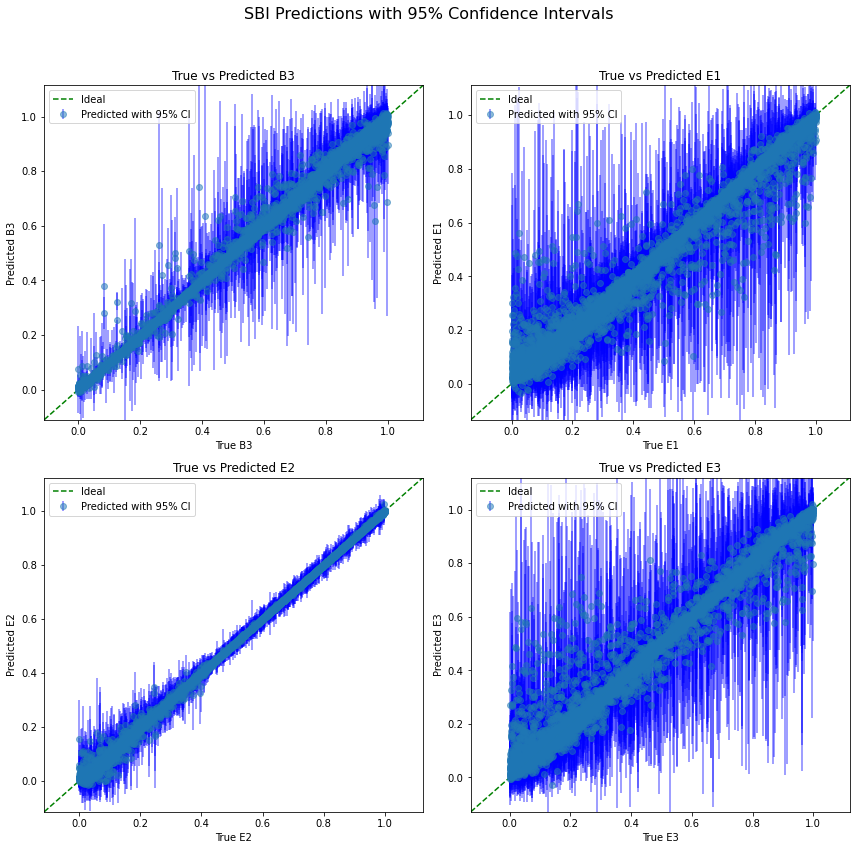

In [39]:
import matplotlib.pyplot as plt

# Assuming the following variables are already computed:
# mean_predictions_train: (num_samples, 4) -> Mean predictions for each target component
# lower_bound: (num_samples, 4) -> Lower bound of confidence interval
# upper_bound: (num_samples, 4) -> Upper bound of confidence interval
# target_data_train: (num_samples, 4) -> True values for each target component

plt.figure(figsize=(12, 12))

# Plot for each target variable
for i, target_name in enumerate(['B3', 'E1', 'E2', 'E3']):
    plt.subplot(2, 2, i + 1)
    
    # Calculate error bars
    errors = [
        mean_predictions_train[:, i] - lower_bound[:, i],  # Lower error
        upper_bound[:, i] - mean_predictions_train[:, i]  # Upper error
    ]
    
    # Scatter plot with error bars
    plt.errorbar(
        target_data_train[:, i],  # True values
        mean_predictions_train[:, i],  # Predicted mean
        yerr=errors,  # Error bars (asymmetric)
        fmt='o',  # Circle marker
        ecolor='blue',  # Error bar color
        alpha=0.5,  # Transparency
        label='Predicted with 95% CI'
    )
    
    # Plot the ideal diagonal line
    min_val = min(target_data_train[:, i].min(), mean_predictions_train[:, i].min()) - 0.1
    max_val = max(target_data_train[:, i].max(), mean_predictions_train[:, i].max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'g--', label='Ideal')
    
    # Set limits, labels, and title
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.xlabel(f'True {target_name}')
    plt.ylabel(f'Predicted {target_name}')
    plt.title(f'True vs Predicted {target_name}')
    plt.legend()

# Adjust layout and add a title for the whole figure
plt.suptitle('SBI Predictions with 95% Confidence Intervals', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to avoid overlap with the suptitle
plt.show()


In [74]:
import time 
predictions_train = []
for i in tqdm(range(len(input_data_train)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = input_data_train[i]  # This is the X and I for this test sample
    # start_time = time.time()
    predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    # end_time = time.time()
    predictions_train.append(predicted_mean)
    # time_taken = end_time - start_time
    # print(f"Time taken for prediction {i+1}: {time_taken:.4f} seconds")
    sys.stdout.flush()  # Manually flush output

Processing samples:  22%|██▏       | 2174/10000 [43:11<2:35:28,  1.19s/it] 


KeyboardInterrupt: 

Convert predictions to numpy array

In [ ]:
predictions_train = torch.stack(predictions_train).detach().numpy()

Scale back the predicted values to original range

In [ ]:
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

Scale back the true values to original range

In [ ]:
B_true_train = scaler_B3.inverse_transform(target_data_train[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(target_data_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_train[:, 3].reshape(-1, 1))
))

Combine the scaled-back true and predicted values for evaluation

In [ ]:
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

Whole model evaluation

In [ ]:
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.0010612602497750234, rMAE: 0.013399032027477432, R²: 0.9979096806199476


Component-wise evaluation

In [ ]:
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

Output the evaluation for each component

In [ ]:
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 9.189484512117416e-06, MAE = 0.0018186406846639467, R² = 0.9972372912425993
E1: MSE = 973.4055932590068, MAE = 19.4137874353984, R² = 0.9970919261569052
E2: MSE = 214.36550793201468, MAE = 7.649406227488236, R² = 0.9993526365946387
E3: MSE = 686.8164204101083, MAE = 13.523675637986855, R² = 0.9979568684856469


Save evaluation metrics to a text file

In [ ]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
#     f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
#     f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
#     f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
#     f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

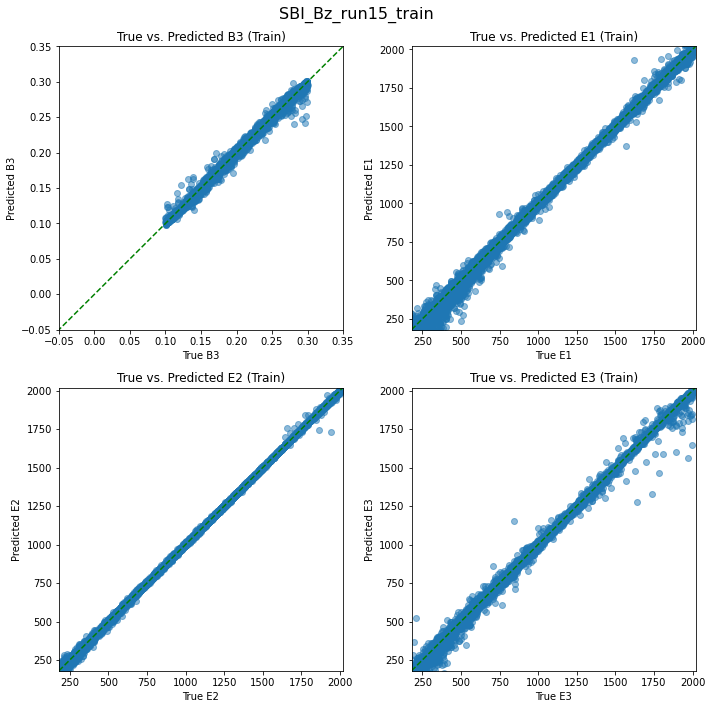

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_train, B_pred_train, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Train)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Train)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Train)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Train)')

plt.suptitle(f'{name_format}_train', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [ ]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


Evaluate the model on the testing set

In [ ]:
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


Generate predictions for the test set

In [40]:
import time
import torch

# Initialize lists to store mean predictions and uncertainties
mean_predictions_test = []
std_dev_predictions_test = []  # For storing uncertainty (standard deviation)

for i in tqdm(range(len(input_data_test)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = input_data_train[i]  # This is the X and I for this training sample
    
    try:
        # Sample the posterior 1000 times for the given input
        predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)
        
        # Extract the mean prediction for B and E
        predicted_mean = predicted_posterior.mean(dim=0)
        predicted_std_dev = predicted_posterior.std(dim=0)  # Calculate standard deviation for uncertainty
        
        # Append the results
        mean_predictions_test.append(predicted_mean)
        std_dev_predictions_test.append(predicted_std_dev)
    
    except Exception as e:
        print(f"Error encountered during prediction for sample {i}: {e}")
        mean_predictions_test.append(torch.tensor([float('nan')] * 4))  # Handle error gracefully
        std_dev_predictions_test.append(torch.tensor([float('nan')] * 4))

    sys.stdout.flush()  # Manually flush output

# Convert lists of tensors to a single tensor for easier manipulation
mean_predictions_test = torch.stack(mean_predictions_test).numpy()  # Shape: (num_samples, 4)
std_dev_predictions_test = torch.stack(std_dev_predictions_test).numpy()  # Shape: (num_samples, 4)

# Calculate confidence intervals (e.g., 95%)
lower_bound = mean_predictions_test - 1.96 * std_dev_predictions_test
upper_bound = mean_predictions_test + 1.96 * std_dev_predictions_test

# Results: `mean_predictions_train`, `std_dev_predictions_train`, `lower_bound`, `upper_bound`
print("Mean Predictions:", mean_predictions_test)
print("Standard Deviations:", std_dev_predictions_test)


Processing samples: 100%|██████████| 10000/10000 [26:29<00:00,  6.29it/s] 
Mean Predictions: [[0.07500856 0.22771044 0.12417367 0.1615023 ]
 [0.5564442  0.4362901  0.4193445  0.3197079 ]
 [0.28934047 0.50560683 0.8937385  0.8930277 ]
 ...
 [0.22119965 0.50336474 0.8456366  0.5233948 ]
 [0.02462391 0.33021086 0.14605218 0.3790284 ]
 [0.85182923 0.18945605 0.5896312  0.09514131]]
Standard Deviations: [[0.08037836 0.06034316 0.03150538 0.09364489]
 [0.00886908 0.02066056 0.0021884  0.01397363]
 [0.00196468 0.02905768 0.00148685 0.01853105]
 ...
 [0.00189405 0.02294321 0.00119782 0.02309972]
 [0.00468326 0.17916687 0.00814144 0.17915304]
 [0.01904397 0.03091181 0.00309564 0.0332531 ]]


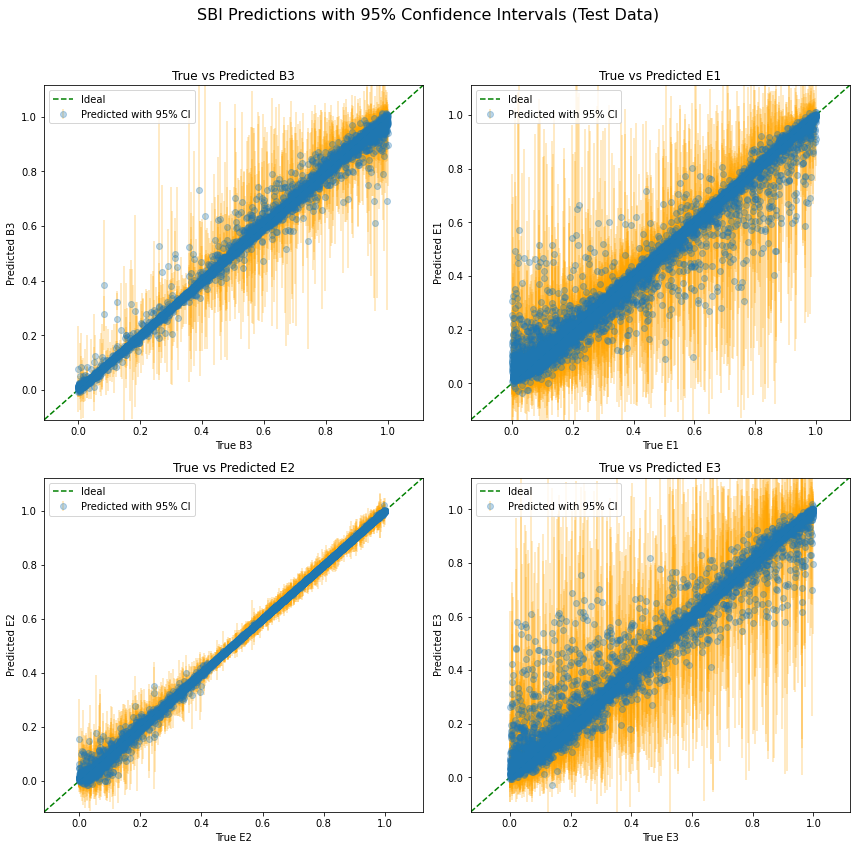

In [44]:
import matplotlib.pyplot as plt

# Assuming the following variables are already computed:
# mean_predictions_train: (num_samples, 4) -> Mean predictions for each target component
# lower_bound: (num_samples, 4) -> Lower bound of confidence interval
# upper_bound: (num_samples, 4) -> Upper bound of confidence interval
# target_data_train: (num_samples, 4) -> True values for each target component

plt.figure(figsize=(12, 12))

# Plot for each target variable
for i, target_name in enumerate(['B3', 'E1', 'E2', 'E3']):
    plt.subplot(2, 2, i + 1)
    
    # Calculate error bars
    errors = [
        mean_predictions_test[:, i] - lower_bound[:, i],  # Lower error
        upper_bound[:, i] - mean_predictions_test[:, i]  # Upper error
    ]
    
    # Scatter plot with error bars
    plt.errorbar(
        target_data_test[:, i],  # True values
        mean_predictions_test[:, i],  # Predicted mean
        yerr=errors,  # Error bars (asymmetric)
        fmt='o',  # Circle marker
        ecolor='orange',  # Error bar color
        alpha=0.5,  # Transparency
        label='Predicted with 95% CI'
    )
    
    # Plot the ideal diagonal line
    min_val = min(target_data_test[:, i].min(), mean_predictions_test[:, i].min()) - 0.1
    max_val = max(target_data_test[:, i].max(), mean_predictions_test[:, i].max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'g--', label='Ideal')
    
    # Set limits, labels, and title
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.xlabel(f'True {target_name}')
    plt.ylabel(f'Predicted {target_name}')
    plt.title(f'True vs Predicted {target_name}')
    plt.legend()

# Adjust layout and add a title for the whole figure
plt.suptitle('SBI Predictions with 95% Confidence Intervals (Test Data)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to avoid overlap with the suptitle
plt.show()


In [ ]:
predictions_test = []
for i in tqdm(range(len(input_data_test)), desc="Processing samples", leave=True, file=sys.stdout):
    test_input = input_data_test[i]  # This is the X and I for this test sample
    predicted_posterior = posterior.sample((1000,), x=test_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    predictions_test.append(predicted_mean)
    
    sys.stdout.flush()  # Manually flush output

Processing samples:  59%|█████▉    | 5905/10000 [12:42<08:22,  8.15it/s]  

                        prior support. It may take a long time to collect the
                        remaining 999 samples. Consider interrupting
                        (Ctrl-C) and switching to `sample_with='mcmc'`.


Processing samples: 100%|██████████| 10000/10000 [25:01<00:00,  6.66it/s]  


Convert predictions to numpy array

In [ ]:
predictions_test = torch.stack(predictions_test).detach().numpy()

Scale back the predicted values to original range for the test data

In [ ]:
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [ ]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

Scale back the true values to original range for the test data

In [ ]:
B_true_test = scaler_B3.inverse_transform(target_data_test[:, 0].reshape(-1, 1))

In [ ]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_data_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_test[:, 3].reshape(-1, 1))
))

Combine the scaled-back true and predicted values for evaluation (test data)

In [ ]:
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

Whole model evaluation

In [ ]:
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.016030359529347, rMAE: 0.0618344728142727, R²: 0.9705099654315281


Component-wise evaluation

In [ ]:
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

Output the evaluation for each component

In [ ]:
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 0.00011092065508157478, MAE = 0.007548295381040689, R² = 0.9666530299097403
E1: MSE = 18959.674003938948, MAE = 95.65963339933892, R² = 0.9433574941152123
E2: MSE = 3070.3929676777216, MAE = 36.960189088810026, R² = 0.9907277058397677
E3: MSE = 6285.619003109293, MAE = 54.6831838850794, R² = 0.9813016318613916


Save evaluation metrics to a text file

In [ ]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
#     f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
#     f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
#     f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
#     f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

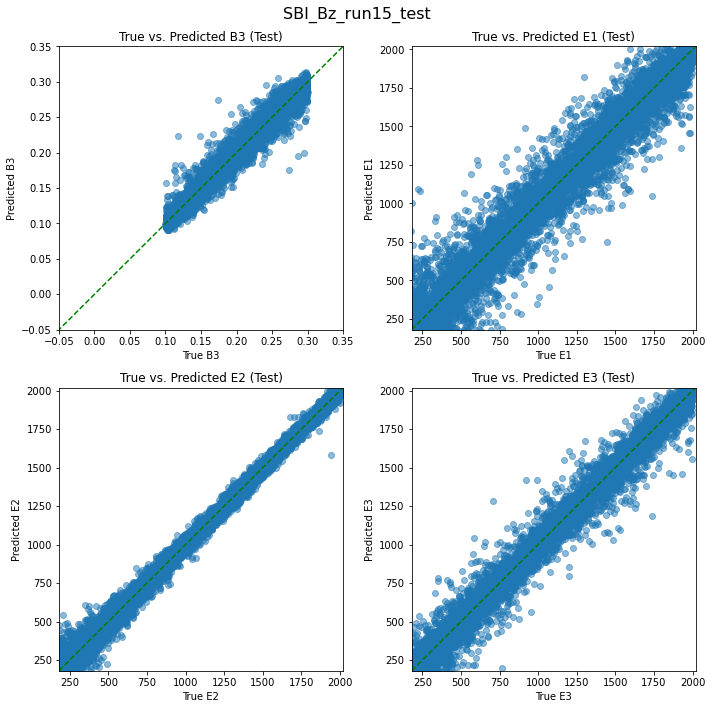

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_test, B_pred_test, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Test)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Test)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Test)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Test)')

plt.suptitle(f'{name_format}_test', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [ ]:
print("Testing set evaluation done.", flush=True)

Testing set evaluation done.
